# SINASC 2024 — heterogeneidade causal exploratória

## 1. Objetivo

Verificar se o contraste ajustado entre início precoce e tardio do pré-natal varia com perfis maternos observáveis. **Exercício didático e exploratório; não identifica automaticamente quem se beneficia de uma intervenção.**

A Fase 3 foi publicada antes desta análise, seguida da padronização em português. A população, T, Y, sete covariáveis e regras de qualidade permanecem congelados. Fonte: SINASC 2024, Parquet e diagnósticos locais com hashes. Unidade: um registro de nascido vivo; chave `contador`.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown, Image
raiz=next(p for p in (Path.cwd(),Path.cwd().parent) if (p/'src').exists()).resolve()
sys.path.insert(0,str(raiz))
assert Path(sys.executable).resolve()==(raiz/'.venv/Scripts/python.exe').resolve(), 'Use a .venv do projeto'
from src.visualizacao_ipt import configurar_plotly,aplicar_tema_ipt
from src.apresentacao_pt import exibir_pt as display, imprimir_pt as print, aplicar_tema_ipt
configurar_plotly()
ler=lambda nome:json.loads((raiz/'outputs/diagnostics'/nome).read_text(encoding='utf-8'))
r=ler('fase4_resultados.json'); ajustes=ler('fase4_ajustes.json')
pd.set_option('display.max_columns',12)

def mostrar(fig,titulo,nome,altura=570):
    aplicar_tema_ipt(fig,titulo)
    fig.update_layout(width=1100,height=altura,margin=dict(l=115,r=55,t=100,b=105))
    fig.update_xaxes(automargin=True); fig.update_yaxes(automargin=True)
    p=raiz/'outputs/figures'/('fase4_'+nome+'.png')
    fig.write_image(p); display(Image(filename=str(p)))

print('Reproduzir ajustes: python -m src.executa_fase4')
print('Resumir: python -m src.resume_fase4')
print('Validar: python -m src.valida_resultados_fase4')


Reproduzir ajustes: python -m src.executa_fase4
Resumir: python -m src.resume_fase4
Validar: python -m src.valida_resultados_fase4


In [2]:
display(pd.DataFrame([{k:r['populacao'][k] for k in ['n','n_t1','n_t0','prevalencia']}]))
print('Covariáveis congeladas:',ajustes['contrato']['x'])


,N,N tratado,N controle,prevalencia
0,2251570,1942045,309525,0.078949


Covariáveis congeladas: ['IDADEMAE_NUM', 'ESCOLARIDADE_MAE', 'RACA_COR_MAE', 'SITUACAO_CONJUGAL', 'PARIDADE_CAT', 'PERDAS_FETAIS_CAT', 'UF_RESIDENCIA']


## 2. O que significa CATE

O CATE candidato é a diferença média entre Y(1) e Y(0) condicional às covariáveis X, na população selecionada. Aqui Y indica baixo peso: valor negativo corresponde a menor risco estimado sob início precoce **apenas sob as hipóteses causais**.

Não observamos os dois desfechos potenciais de uma pessoa. A variação das previsões pode representar estrutura do contraste, erro amostral, especificação do modelo ou confundimento residual. Não é uma medida verificada de benefício individual.

## 3. Limitações

Dados observacionais e selecionados entre nascidos vivos. Renda, tabagismo, nutrição, morbidades e acesso/qualidade permanecem incompletamente medidos. Temporalidade de X e mensuração do mês são limitantes. A estabilidade não resolve a identificação causal.

Os intervalos apresentados são de **contrastes DR de avaliação**, com funções aprendidas tratadas como fixas. Não são intervalos individuais de CATE. A dispersão das previsões não é o erro-padrão do modelo aprendido. Rotação das amostras também cria dependência entre resultados combinados.

## 4. DR-Learner

Primeiro estimar e(X), m0(X), m1(X). Depois construir:

`psi = m1 − m0 + T(Y−m1)/e − (1−T)(Y−m0)/(1−e)`

Finalmente, aprender E[psi|X] por HistGradientBoostingRegressor: 100 iterações, até 7 folhas, mínimo de 2.000 registros por folha, regularização L2=1 e semente 20240925. Sem busca de hiperparâmetros. Comparação simples: Ridge com alpha=10. Modelos auxiliares compatíveis com C2 da Fase 2: propensão logística e desfechos HGB.

[Fundamentação do DR-Learner](https://arxiv.org/html/2004.14497v3). A teoria não certifica automaticamente o desempenho deste estimador específico no SINASC agrupado.

## 5. Ajuste cruzado e honestidade

Três partições de municípios, sorteadas sem usar T/Y. Em cada rotação: **A** ajusta os auxiliares; **B** recebe previsões externas, constrói psi e ajusta o CATE; **C** recebe CATE e fornece avaliação externa. Cada nascimento é avaliado uma vez. Nenhum município de C aparece em A/B; codificação e imputação são ajustadas dentro do treino correspondente.

Essa separação evita vazamento indireto de Y de C através dos modelos auxiliares. Não foram reutilizados os pseudo-desfechos da Fase 2 em uma segunda divisão ingênua. Há perda de eficiência, pois cada etapa usa aproximadamente um terço da população.


In [3]:
display(pd.DataFrame(ajustes['contrato']['particoes']))
display(pd.DataFrame([{k:v for k,v in x.items() if k not in ['ajustes','indices_sha256']} for x in ajustes['rotacoes']]))
print('UF 53 aparece somente em uma partição municipal; na sua avaliação, é categoria nova nos dois treinos. Isso limita a generalização para o DF.')


,particao,N,N tratado,N controle,n y1,n municipios
0,1,756684,656380,100304,60203,1861
1,2,694101,598189,95912,54412,1860
2,3,800785,687476,113309,63144,1860


,rodada,particao auxiliares,particao cate,particao avaliacao,n auxiliares,n cate,n avaliacao,intersecoes registros,intersecoes municipios,uf nova no cate,uf nova nos auxiliares
0,1,1,2,3,756684,694101,800785,0,0,[53],[53]
1,2,2,3,1,694101,800785,756684,0,0,[],[]
2,3,3,1,2,800785,756684,694101,0,0,[],[]


UF 53 aparece somente em uma partição municipal; na sua avaliação, é categoria nova nos dois treinos. Isso limita a generalização para o DF.


## 6. Distribuição de CATE

Valores em pontos percentuais. O intervalo p5–p95 resume a distribuição prevista; não é intervalo de confiança. Nenhuma previsão foi recortada ou limitada artificialmente.


,0,1
modelo,HGB principal,Ridge
N,2251570,2251570
media pp,-1.2941,-1.301716
mediana pp,-1.289838,-1.319723
p05 pp,-3.92382,-3.235409
p25 pp,-1.962784,-2.114341
p75 pp,-0.427044,-0.513669
p95 pp,1.208079,0.71117
amplitude robusta pp,5.131899,3.946578
min pp,-33.251066,-20.56627


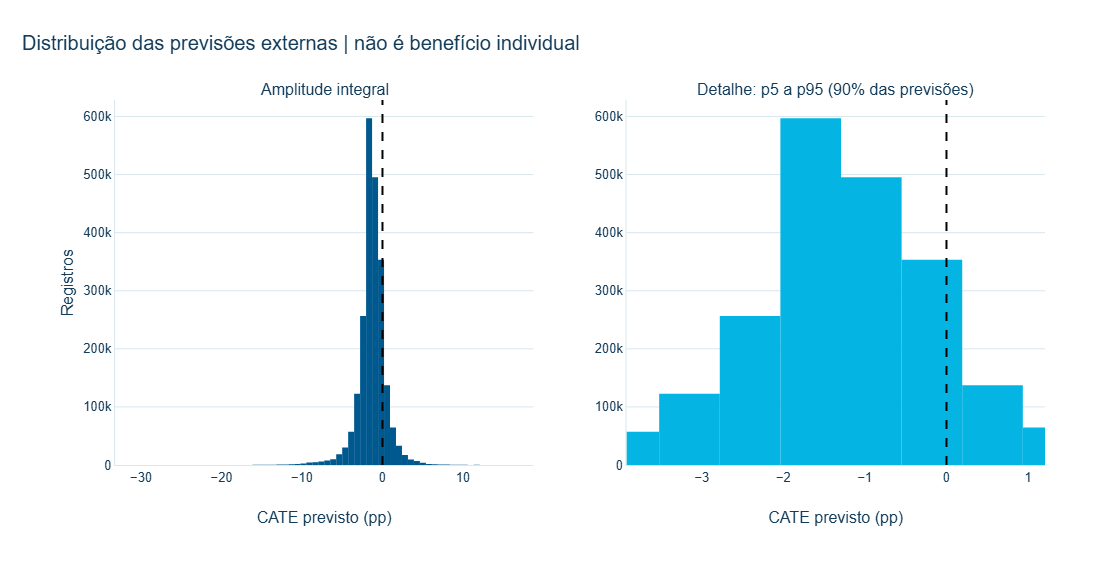

In [4]:
display(pd.DataFrame([dict(modelo='HGB principal',**r['principal']),dict(modelo='Ridge',**r['alternativo'])]).T)
h=r['histograma']; limites=np.array(h['limites_pp'])
fig=make_subplots(rows=1,cols=2,subplot_titles=['Amplitude integral','Detalhe: p5 a p95 (90% das previsões)'])
for j in [1,2]:
    fig.add_bar(x=(limites[1:]+limites[:-1])/2,y=h['contagens'],width=np.diff(limites),name='Nascimentos',showlegend=False,row=1,col=j)
    fig.add_vline(x=0,line_dash='dash',row=1,col=j)
fig.update_xaxes(title='CATE previsto (pp)')
fig.update_xaxes(range=[r['principal']['p05_pp'],r['principal']['p95_pp']],row=1,col=2)
fig.update_yaxes(title='Registros',row=1,col=1)
mostrar(fig,'Distribuição das previsões externas | não é benefício individual','distribuicao')


## 7. Perfis maternos pré-especificados

Idade, escolaridade, raça/cor e paridade. Códigos categóricos originais permanecem explícitos; não constituem ordenação de prioridade. As médias de CATE descrevem o que o modelo aprendeu; o contraste DR usa o pseudo-desfecho de avaliação. Seus intervalos municipais aproximados não incluem toda a incerteza dos modelos nem ajuste para múltiplas comparações.


### Faixa etária

,grupo,N,media pp,p05 pp,mediana pp,p95 pp,contraste dr pp,ic95 dr inferior pp,ic95 dr superior pp
0,20–29,1111506,-1.1925,-2.9392,-1.2817,0.6521,-1.1417,-1.3105,-0.9729
1,30–34,476754,-1.1882,-3.7875,-1.1567,1.3695,-1.1348,-1.4439,-0.8258
2,<20,257765,-1.2145,-3.4272,-1.3705,1.3900,-1.0961,-1.4570,-0.7353
3,Ausente,32,-2.5024,-6.2852,-3.4152,4.6544,-14.5087,-45.0896,16.0723
4,≥35,405513,-1.7475,-6.9654,-1.4827,2.4871,-1.5925,-1.9726,-1.2124


### Escolaridade

,grupo,N,media pp,p05 pp,mediana pp,p95 pp,contraste dr pp,ic95 dr inferior pp,ic95 dr superior pp
5,0,4971,-2.2030,-6.9386,-1.8520,1.2551,-1.6609,-3.8906,0.5688
6,1,43866,-2.7951,-7.6425,-2.3899,1.0482,-2.9388,-3.7398,-2.1378
7,2,378758,-1.4969,-3.9932,-1.4501,0.7144,-1.5688,-1.8372,-1.3003
8,3,1253913,-1.3050,-3.2990,-1.3185,0.6328,-1.2344,-1.4109,-1.0578
9,4,116498,-1.1543,-4.0901,-1.0429,1.2807,-0.9521,-1.4966,-0.4077
10,5,442808,-0.9446,-4.9801,-0.8411,2.8828,-0.7208,-1.0871,-0.3545
11,IGNORADO,10756,-2.2370,-5.8655,-1.9373,0.6263,-2.7508,-4.2327,-1.2689


### Raça/cor

,grupo,N,media pp,p05 pp,mediana pp,p95 pp,contraste dr pp,ic95 dr inferior pp,ic95 dr superior pp
12,1,752659,-1.3009,-4.0652,-1.3597,1.3812,-1.2168,-1.4716,-0.9620
13,2,178771,-1.4824,-4.0620,-1.4602,0.7845,-1.4296,-1.8361,-1.0231
14,3,10390,-0.9933,-4.6485,-0.9120,2.2471,0.0944,-1.8730,2.0617
15,4,1254815,-1.2290,-3.6727,-1.2138,1.1213,-1.1785,-1.3513,-1.0057
16,5,26785,-1.4100,-5.0142,-1.1836,1.0218,-1.4714,-2.6102,-0.3327
17,IGNORADO,28150,-2.8211,-9.5201,-1.9207,1.6905,-1.7842,-3.3231,-0.2454


### Paridade

,grupo,N,media pp,p05 pp,mediana pp,p95 pp,contraste dr pp,ic95 dr inferior pp,ic95 dr superior pp
18,0,831132,-1.4712,-3.9819,-1.5027,1.1625,-1.4459,-1.6924,-1.1993
19,1,1420438,-1.1905,-3.8732,-1.1377,1.2206,-1.0821,-1.2422,-0.9221


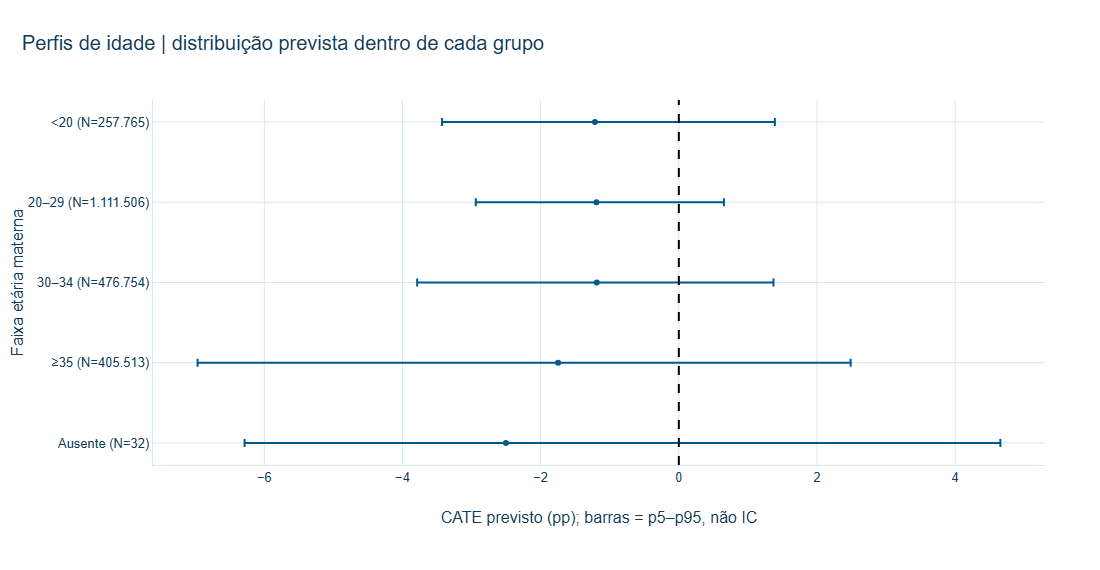

In [5]:
perfis=pd.DataFrame(r['perfis'])
for dim in ['Faixa etária','Escolaridade','Raça/cor','Paridade']:
    display(Markdown('### '+dim))
    display(perfis.loc[perfis.dimensao==dim,['grupo','n','media_pp','p05_pp','mediana_pp','p95_pp','contraste_dr_pp','ic95_dr_inferior_pp','ic95_dr_superior_pp']].round(4))
d=perfis[perfis.dimensao=='Faixa etária']
d=d.assign(ordem=d.grupo.map({'<20':0,'20–29':1,'30–34':2,'≥35':3,'Ausente':4})).sort_values('ordem',ascending=False)
rotulos=[g+' (N='+format(int(n),',').replace(',','.')+')' for g,n in zip(d.grupo,d.n)]
fig=go.Figure(go.Scatter(x=d.media_pp,y=rotulos,mode='markers',name='Média prevista',
    error_x=dict(type='data',symmetric=False,array=d.p95_pp-d.media_pp,arrayminus=d.media_pp-d.p05_pp)))
fig.add_vline(x=0,line_dash='dash'); fig.update_xaxes(title='CATE previsto (pp); barras = p5–p95, não IC')
fig.update_yaxes(title='Faixa etária materna')
mostrar(fig,'Perfis de idade | distribuição prevista dentro de cada grupo','idade')


## 8. Quintis de CATE

Quintis globais crescentes, com N aproximadamente igual. Empates repartidos aleatoriamente com semente fixa, independentemente de Y; pessoas empatadas não têm efeitos previstos diferentes por estarem em quintis distintos.

Idade média e proporções das seis covariáveis categóricas caracterizam a composição. A prevalência de Y é **somente descritiva**. Quintis não significam melhores pacientes para tratar e os contrastes brutos de Y não validam o CATE.


,quintil,N,cate medio pp,ridge medio pp,idade media,prevalencia observada pct,proporcao t1 pct,cate min pp,cate max pp
0,1,450314,-3.61815,-2.44343,29.92691,9.18159,86.53051,-33.25107,-2.20036
1,2,450314,-1.82901,-1.91807,26.39360,8.19228,86.03774,-2.20036,-1.53765
2,3,450314,-1.27330,-1.30235,26.39235,7.52542,85.47414,-1.53765,-0.96143
3,4,450314,-0.61102,-0.75487,27.26672,7.07662,85.64402,-0.96143,-0.23154
4,5,450314,0.86098,-0.08987,28.71575,7.49855,87.57822,-0.23154,18.77290


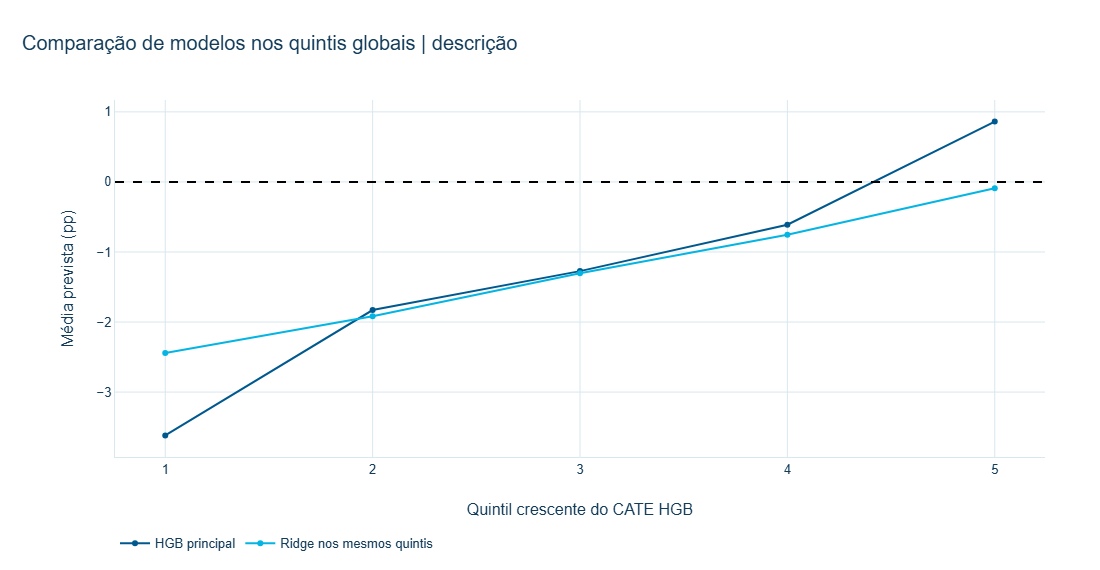

In [6]:
qs=pd.DataFrame(r['quintis']); display(qs.round(5))
fig=go.Figure()
for coluna,nome in [('cate_medio_pp','HGB principal'),('ridge_medio_pp','Ridge nos mesmos quintis')]:
    fig.add_scatter(x=qs.quintil,y=qs[coluna],mode='lines+markers',name=nome)
fig.update_xaxes(title='Quintil crescente do CATE HGB',dtick=1)
fig.update_yaxes(title='Média prevista (pp)'); fig.add_hline(y=0,line_dash='dash')
mostrar(fig,'Comparação de modelos nos quintis globais | descrição','quintis')


In [7]:
composicao=pd.DataFrame(r['quintis_composicao_x'])
for variavel in ajustes['contrato']['x'][1:]:
    display(Markdown('**'+variavel+' — composição (%)**'))
    display(composicao[composicao.variavel==variavel].pivot(index='categoria',columns='quintil',values='percentual').fillna(0).round(2))


**ESCOLARIDADE_MAE — composição (%)**

,1,2,3,4,5
categoria,,,,,
0,0.49,0.14,0.13,0.12,0.22
1,5.24,1.29,0.92,0.89,1.40
2,19.50,20.20,15.04,17.64,11.73
3,47.70,58.66,68.55,57.63,45.91
4,4.65,4.52,4.48,5.70,6.52
5,21.39,14.76,10.52,17.75,33.91
IGNORADO,1.04,0.42,0.37,0.25,0.30


**RACA_COR_MAE — composição (%)**

,1,2,3,4,5
categoria,,,,,
1,34.24,35.82,32.92,29.52,34.64
2,8.86,9.20,8.20,7.51,5.93
3,0.54,0.30,0.29,0.36,0.82
4,52.01,53.20,56.77,60.53,56.14
5,1.47,0.75,1.09,1.24,1.40
IGNORADO,2.88,0.72,0.74,0.83,1.08


**SITUACAO_CONJUGAL — composição (%)**

...

,1,2,3,4,5
categoria,,,,,
0,45.7,44.56,34.99,27.8,31.51
1,54.3,55.44,65.01,72.2,68.49


**PERDAS_FETAIS_CAT — composição (%)**

,1,2,3,4,5
categoria,,,,,
0,72.78,83.54,82.69,76.94,68.47
1,20.71,12.61,13.60,17.73,19.19
2_OU_MAIS,4.73,2.62,2.34,3.44,9.22
IGNORADO,1.79,1.23,1.37,1.88,3.11


**UF_RESIDENCIA — composição (%)**

,1,2,3,4,5
categoria,,,,,
11,1.12,0.80,0.38,0.52,1.35
12,0.13,0.12,0.30,0.55,1.53
13,0.88,1.03,5.48,3.09,3.43
14,1.31,0.67,0.26,0.14,0.08
15,3.10,3.50,5.62,8.97,2.87
16,0.08,0.22,0.28,0.48,1.54
17,0.89,0.78,0.48,1.11,1.43
21,1.04,1.41,2.43,7.08,7.15
22,3.09,1.82,1.45,0.97,0.80


## 9. Diagnósticos de estabilidade

**Modelo:** correlação HGB/Ridge, discrepância absoluta e concordância de sinal nas previsões externas.

**Partições:** distribuição e médias de perfis comparadas entre conjuntos geográficos distintos. Para as correlações, usar categorias com N≥1.000 em cada conjunto comparado. Diferenças também podem refletir composição geográfica.

**Separação externa:** em cada conjunto C, recalcular quintis localmente e comparar a média de psi em Q5 e Q1. Como a ordem é crescente, uma diferença positiva é compatível com a ordenação prevista. O IC é municipal, condicional às funções fixas. As três rotações compartilham dados em papéis diferentes; não são três estudos independentes.


,0
spearman hgb ridge,0.706556
diferenca absoluta media pp,0.881772
concordancia sinal,0.863330
mediana spearman perfis,0.157895


,particao,N,media pp,mediana pp,p05 pp,p25 pp,...,proporcao negativa,proporcao positiva,proporcao zero,n fora limite teorico,media psi pp,media ridge pp
0,1,756684,-1.56381,-1.50944,-4.22983,-2.24349,...,0.88427,0.11573,0.0,0,-1.08114,-1.56718
1,2,694101,-0.97407,-1.05534,-3.60628,-1.73601,...,0.79544,0.20456,0.0,0,-1.25634,-0.99553
2,3,800785,-1.31664,-1.29957,-3.89373,-1.87850,...,0.85603,0.14397,0.0,0,-1.30963,-1.31626


,particao1,particao2,n categorias,spearman
0,1,2,19,0.15439
1,1,3,19,0.15789
2,2,3,19,0.63158


,particao,N,n q1,n q5,contraste dr q5 q1 pp,se municipal pp,ic95 inferior pp,ic95 superior pp,contraste cate q5 q1 pp
0,1,756684,151337,151336,0.95366,0.45896,0.05353,1.85379,4.24459
1,2,694101,138821,138820,1.67282,0.42657,0.83622,2.50942,4.72730
2,3,800785,160157,160157,1.48863,0.40426,0.69578,2.28147,4.36540


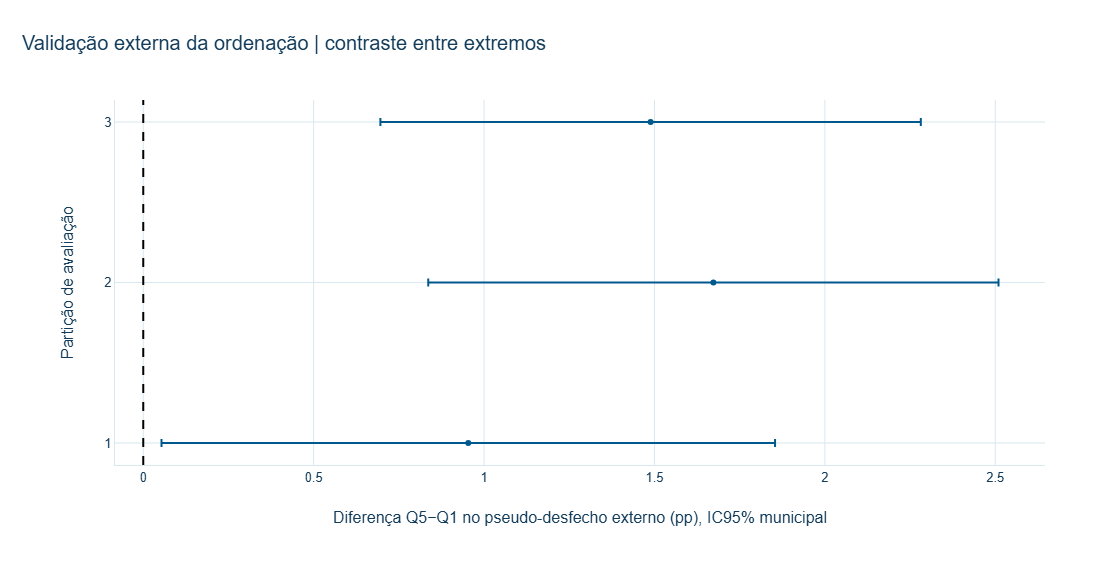

In [8]:
e=r['estabilidade']
display(pd.DataFrame([{k:e[k] for k in ['spearman_hgb_ridge','diferenca_absoluta_media_pp','concordancia_sinal','mediana_spearman_perfis']}]).T)
display(pd.DataFrame(e['distribuicao_particao']).round(5))
display(pd.DataFrame(e['correlacoes_perfis']).round(5))
externo=pd.DataFrame(e['contrastes_externos'])
display(externo.drop(columns='metodo').round(5))
fig=go.Figure(go.Scatter(x=externo.contraste_dr_q5_q1_pp,y=externo.particao.astype(str),mode='markers',name='Contraste DR externo',
    error_x=dict(type='data',symmetric=False,array=externo.ic95_superior_pp-externo.contraste_dr_q5_q1_pp,
    arrayminus=externo.contraste_dr_q5_q1_pp-externo.ic95_inferior_pp)))
fig.add_vline(x=0,line_dash='dash')
fig.update_xaxes(title='Diferença Q5−Q1 no pseudo-desfecho externo (pp), IC95% municipal')
fig.update_yaxes(title='Partição de avaliação',type='category')
mostrar(fig,'Validação externa da ordenação | contraste entre extremos','validacao')


## 10. Relação entre ATE e CATE

Na população-alvo, o ATE é a média do CATE verdadeiro, sob as mesmas hipóteses. A média de previsões regularizadas não precisa coincidir exatamente com a média dos pseudo-desfechos, nem com C2 histórico: há separação diferente e menos dados por ajuste. Nenhuma previsão foi recentrada para forçar concordância.


In [9]:
display(pd.DataFrame([{k:r[k] for k in ['media_psi_pp','diferenca_media_cate_psi_pp','ate_fase2_c2_pp']}]).T); print('Média CATE HGB (pp):',r['principal']['media_pp'])

,0
media psi pp,-1.216412
diferenca media cate psi pp,-0.077689
ate fase2 c2 pp,-1.231456


Média CATE HGB (pp): -1.294100493864875


## 11. Exercício de decisão — somente conceito

Se houvesse capacidade limitada para promover início precoce, seria necessário definir a intervenção, seus custos e elegibilidade, avaliar valor esperado em dados independentes e realizar validação prospectiva com critérios de equidade. A intervenção de promoção não é equivalente a observar início precoce. Sem efeito identificado dessa ação e sem custos, não há ROI defensável.

O modelo atual **não recomenda tratamento, retirada de cuidado, alocação clínica ou política pública**. Um sinal previsto não determina a verdade individual. Causal Forest foi omitido para manter a fase parcimoniosa e sem novas dependências.

## 12. Critério de decisão

As regras operacionais foram registradas antes do ajuste. A classificação considera avaliação externa, comparação de modelos e estabilidade entre partições; não usa apenas a dispersão das previsões. Os limiares são critérios exploratórios deste exercício, não testes universais.

[Protocolo, resultados e limitações](../docs/methodology/HETEROGENEIDADE_FASE4.md). Os critérios históricos das Fases 1–3 permanecem registrados. Nenhuma Fase 5 foi iniciada.


In [10]:
from src.valida_resultados_fase4 import validar
validacao=validar()
assert validacao['status']=='APROVADO'
display(Markdown('**'+r['gate']+'**'))
print('Causalidade provada: NÃO. Recomendação clínica: NÃO.')


{
  "status": "APROVADO",
  "n": 2251570,
  "n_t1": 1942045,
  "n_t0": 309525,
  "cobertura_unica": true,
  "papeis_municipais_disjuntos": true,
  "pseudo_desfecho_reconciliado": true,
  "quintis_e_perfis_reconciliados": true,
  "historico_fases_0_3_preservado": true,
  "tolerancia_absoluta_score": 1e-12,
  "tolerancia_resumos": 1e-10,
  "gate": "HETEROGENEIDADE_SENSIVEL_A_MODELO"
}


**HETEROGENEIDADE_SENSIVEL_A_MODELO**

Causalidade provada: NÃO. Recomendação clínica: NÃO.
